# **Notebook PC#03 (Part B2)**
# MLP classifier for the CIFAR-10 database.
#### Grid search for the hyperparameters. Code partially produced by previous students of IA353. Thank you for making PC#03 still more complete and informative.
**Professor:** Fernando J. Von Zuben <br>
**Cursos:** IA353A / EG453A (FEEC/Unicamp) - 1s2026 <br>
**Aluno(a):** Daniele Souza Gonçalves **RA:** 248029 <br>
**Aluno(a):** Joao Lucas Morais Ortiz **RA:** 297611 <br>

In [1]:
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import gc

cifar10 = tf.keras.datasets.cifar10

(x_train, y_train),(x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

In [2]:
def model_and_evaluate(n_neurons = 1024,
                       n_layers  = 1,
                       dropout   = 0.25,
                       epochs    = 10,
                       optimizer = 'adam',
                       verbose   = 1):
    gc.collect()
    tf.keras.backend.clear_session()

    model = tf.keras.models.Sequential([
          tf.keras.layers.Flatten(),
          tf.keras.layers.Dense(n_neurons,activation=tf.nn.relu),
          tf.keras.layers.Dropout(dropout)])

    if n_layers > 1:
        for _ in range(n_layers-1):
            model.add(tf.keras.layers.Dense(n_neurons,activation=tf.nn.relu))
            model.add(tf.keras.layers.Dropout(dropout))

    model.add(tf.keras.layers.Dense(10, activation=tf.nn.softmax))
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(x_train, y_train, epochs=epochs, verbose=verbose)

    loss, accuracy = model.evaluate(x_test, y_test,verbose=verbose)

    if verbose:
        model.summary()
        # Evaluate the model on the test data using `evaluate`
        print("Evaluate on test data")
        print("test loss, test acc:", loss, accuracy)

    train_result = dict(n_neurons = n_neurons,
                        n_layers  = n_layers,
                        optimizer = optimizer,
                        dropout   = dropout,
                        epochs    = epochs,
                        loss      = loss,
                        accuracy  = accuracy)
    return loss, accuracy

In [3]:
n_repetitions = 5
DEFAULT = {
    'n_neurons' : 1024,
    'n_layers'  : 1,
    'dropout'   : 0.25,
    'epochs'    : 10,
    'optimizer' : 'adam'
}

df = pd.DataFrame(columns=['n_neurons', 'n_layers', 'dropout', 'epochs','optimizer'] + \
                          [f"{metric} {iteration}" for iteration in range(1, n_repetitions+1) for metric in ['loss', 'accuracy']])

In [4]:
args = DEFAULT.copy()
row = list(args.values())
for iter in tqdm(range(n_repetitions)):
        loss, accuracy = model_and_evaluate(verbose=0)

        row.append(loss)
        row.append(accuracy)
df.loc[0] = row

  0%|          | 0/5 [00:00<?, ?it/s]

2026-04-19 21:35:13.330790: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-19 21:35:13.330818: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-19 21:35:13.330829: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-19 21:35:13.331168: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-19 21:35:13.331646: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2026-04-19 21:35:16.088309: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [5]:
for n_neurons in [512, 2048, 4096]:
    args = DEFAULT.copy()
    args['n_neurons'] = n_neurons

    row = list(args.values())

    for iter in tqdm(range(n_repetitions)):
        loss, accuracy = model_and_evaluate(n_neurons=n_neurons, verbose=0)

        row.append(loss)
        row.append(accuracy)

    df.loc[f'n_neurons={n_neurons}'] = row


  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [6]:
for n_layers in [2, 3, 4]:
    args = DEFAULT.copy()
    args['n_layers'] = n_layers

    row = list(args.values())

    for iter in tqdm(range(n_repetitions)):
        loss, accuracy = model_and_evaluate(n_layers=n_layers, verbose=0)

        row.append(loss)
        row.append(accuracy)

    df.loc[f'n_layers={n_layers}'] = row

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [7]:
for dropout in [0, 0.5]:
    args = DEFAULT.copy()
    args['dropout'] = dropout

    row = list(args.values())

    for iter in tqdm(range(n_repetitions)):
        loss, accuracy = model_and_evaluate(dropout=dropout, verbose=0)

        row.append(loss)
        row.append(accuracy)

    df.loc[f'dropout={dropout}'] = row

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [8]:
for optimizer in ['RMSprop', 'SGD']:
    args = DEFAULT.copy()
    args['optimizer'] = optimizer

    row = list(args.values())

    for iter in tqdm(range(n_repetitions)):
        loss, accuracy = model_and_evaluate(optimizer=optimizer, verbose=0)

        row.append(loss)
        row.append(accuracy)

    df.loc[f'optimizer={optimizer}'] = row

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [9]:
for epochs in [5, 20, 30]:
    args = DEFAULT.copy()
    args['epochs'] = epochs

    row = list(args.values())

    for iter in tqdm(range(n_repetitions)):
        loss, accuracy = model_and_evaluate(epochs=epochs, verbose=0)

        row.append(loss)
        row.append(accuracy)

    df.loc[f'epochs={epochs}'] = row

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

In [10]:
df.to_csv('cifar10_PC03_MLP_analysis.csv',index=False)
df.head()

,n_neurons,n_layers,dropout,epochs,optimizer,loss 1,accuracy 1,loss 2,accuracy 2,loss 3,accuracy 3,loss 4,accuracy 4,loss 5,accuracy 5
0,1024,1,0.25,10,adam,3.052634,0.2559,2.870798,0.2478,2.707824,0.2620,3.512713,0.2368,4.107641,0.1926
n_neurons=512,512,1,0.25,10,adam,2.753642,0.2126,2.379112,0.2831,2.708369,0.2360,2.532868,0.2335,2.374587,0.2773
n_neurons=2048,2048,1,0.25,10,adam,4.429619,0.2660,3.600660,0.2581,5.128207,0.1972,4.796773,0.2516,4.177035,0.2422
n_neurons=4096,4096,1,0.25,10,adam,6.074740,0.2712,6.170599,0.2638,8.306355,0.2243,13.041336,0.2425,7.209147,0.1971
n_layers=2,1024,2,0.25,10,adam,46.461033,0.1080,37.487858,0.1532,124.375160,0.1323,109.800987,0.1374,32.142082,0.1103


In [11]:
df = pd.read_csv('cifar10_PC03_MLP_analysis.csv')
df.head()

,n_neurons,n_layers,dropout,epochs,optimizer,loss 1,accuracy 1,loss 2,accuracy 2,loss 3,accuracy 3,loss 4,accuracy 4,loss 5,accuracy 5
0,1024,1,0.25,10,adam,3.052634,0.2559,2.870798,0.2478,2.707824,0.2620,3.512713,0.2368,4.107641,0.1926
1,512,1,0.25,10,adam,2.753642,0.2126,2.379112,0.2831,2.708369,0.2360,2.532868,0.2335,2.374587,0.2773
2,2048,1,0.25,10,adam,4.429619,0.2660,3.600660,0.2581,5.128207,0.1972,4.796773,0.2516,4.177035,0.2422
3,4096,1,0.25,10,adam,6.074740,0.2712,6.170599,0.2638,8.306355,0.2243,13.041336,0.2425,7.209147,0.1971
4,1024,2,0.25,10,adam,46.461033,0.1080,37.487858,0.1532,124.375160,0.1323,109.800987,0.1374,32.142082,0.1103


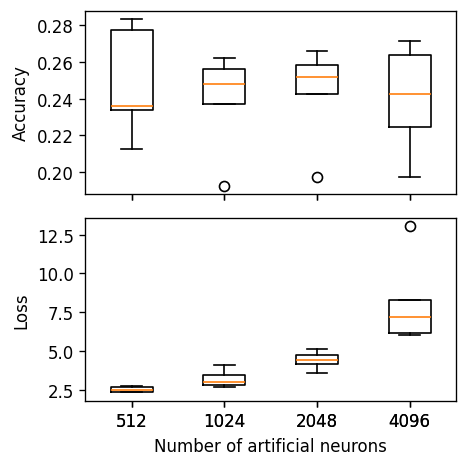

In [12]:
losses = np.zeros((n_repetitions, 4))
accurs = np.zeros((n_repetitions, 4))

# The list of n_neurons to iterate through. This determines the order of columns in losses/accurs.
n_neurons_list_for_plot = [512, 1024, 2048, 4096]

for i, n_neurons_val in enumerate(n_neurons_list_for_plot):
    sample = df[(df['n_neurons'] == n_neurons_val) & (df['n_layers'] == 1) & (df['dropout'] == 0.25) & (df['optimizer'] == 'adam') & (df['epochs'] == 10)]

    if sample.empty:
        # This case should ideally not be reached with the fix if df is correctly populated.
        # If it does, it implies a data generation issue or an unexpected filter combination.
        print(f"Warning: No data found for n_neurons={n_neurons_val}, n_layers=1, dropout=0.25, optimizer='adam', epochs=10. Skipping this configuration.")
        continue # Skip this iteration if no data is found

    # Fix 2: Use a different variable (j) for the inner loop to construct column names for loss/accuracy.
    # Fix 3: Flatten the numpy array result to match the target slice shape.
    loss_cols = [f'loss {j}' for j in range(1, n_repetitions+1)]
    accy_cols = [f'accuracy {j}' for j in range(1, n_repetitions+1)]

    loss = sample[loss_cols].to_numpy().flatten()
    accy = sample[accy_cols].to_numpy().flatten()

    losses[:, i] = loss
    accurs[:, i] = accy

fig,ax=plt.subplots(2,1,figsize=(4,4),dpi=120,sharex=True)

# Fix 4: The tick_labels should correspond to the order of n_neurons_list_for_plot
ax[0].boxplot(accurs, tick_labels=n_neurons_list_for_plot)
ax[1].boxplot(losses, tick_labels=n_neurons_list_for_plot)

ax[0].set_ylabel('Accuracy')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Number of artificial neurons')
fig.align_ylabels()
plt.tight_layout()

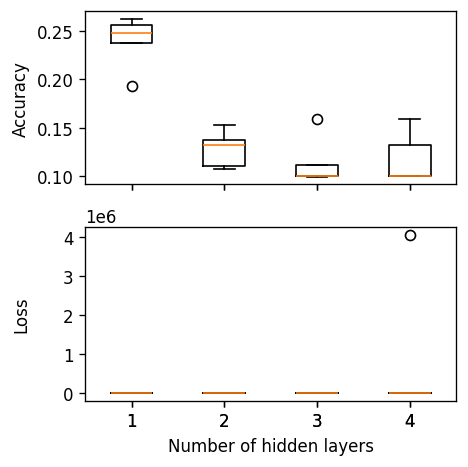

In [13]:
losses = np.zeros((n_repetitions, 4))
accurs = np.zeros((n_repetitions, 4))

for i, n_layers in enumerate([1,2,3,4]):
    sample = df[(df['n_neurons'] == 1024) & (df['n_layers'] == n_layers)& (df['dropout'] == 0.25) & (df['optimizer'] == 'adam') & (df['epochs'] == 10)]
    loss   = sample[[f'loss {i}' for i in  range(1, n_repetitions+1)]].to_numpy()
    accy   = sample[[f'accuracy {i}' for i in  range(1, n_repetitions+1)]].to_numpy()

    losses[:, i] = loss
    accurs[:, i] = accy

fig,ax=plt.subplots(2,1,figsize=(4,4),dpi=120,sharex=True)

ax[0].boxplot(accurs, tick_labels=[1,2,3,4])
ax[1].boxplot(losses, tick_labels=[1,2,3,4])

ax[0].set_ylabel('Accuracy')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Number of hidden layers')
fig.align_ylabels()
plt.tight_layout()

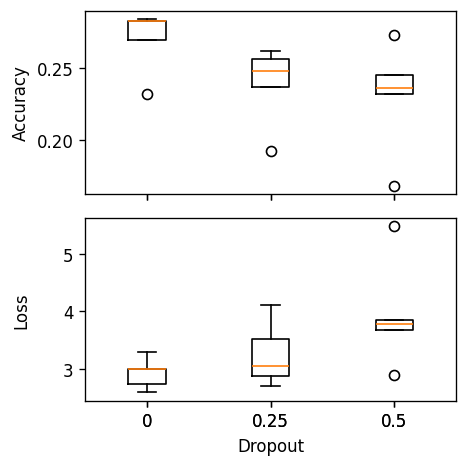

In [14]:
losses = np.zeros((n_repetitions, 3))
accurs = np.zeros((n_repetitions, 3))

for i, dropout in enumerate([0, 0.25, 0.5]):
    sample = df[(df['n_neurons'] == 1024) & (df['n_layers'] == 1)& (df['dropout'] == dropout) & (df['optimizer'] == 'adam') & (df['epochs'] == 10)]
    loss   = sample[[f'loss {i}' for i in  range(1, n_repetitions+1)]].to_numpy()
    accy   = sample[[f'accuracy {i}' for i in  range(1, n_repetitions+1)]].to_numpy()

    losses[:, i] = loss
    accurs[:, i] = accy

fig,ax=plt.subplots(2,1,figsize=(4,4),dpi=120,sharex=True)

ax[0].boxplot(accurs, tick_labels=[0,0.25,0.5])
ax[1].boxplot(losses, tick_labels=[0,0.25,0.5])

ax[0].set_ylabel('Accuracy')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Dropout')
fig.align_ylabels()
plt.tight_layout()

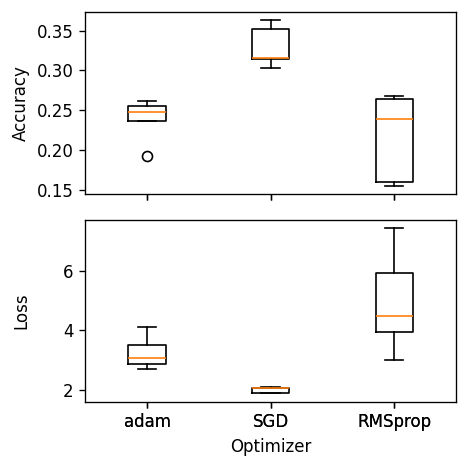

In [15]:
losses = np.zeros((n_repetitions, 3))
accurs = np.zeros((n_repetitions, 3))

for i, optimizer in enumerate(['adam','SGD','RMSprop']):
    sample = df[(df['n_neurons'] == 1024) & (df['n_layers'] == 1)& (df['dropout'] == 0.25) & (df['optimizer'] == optimizer) & (df['epochs'] == 10)]
    loss   = sample[[f'loss {i}' for i in  range(1, n_repetitions+1)]].to_numpy()
    accy   = sample[[f'accuracy {i}' for i in  range(1, n_repetitions+1)]].to_numpy()

    losses[:, i] = loss
    accurs[:, i] = accy

fig,ax=plt.subplots(2,1,figsize=(4,4),dpi=120,sharex=True)

ax[0].boxplot(accurs, tick_labels=['adam','SGD','RMSprop'])
ax[1].boxplot(losses, tick_labels=['adam','SGD','RMSprop'])

ax[0].set_ylabel('Accuracy')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Optimizer')
fig.align_ylabels()
plt.tight_layout()

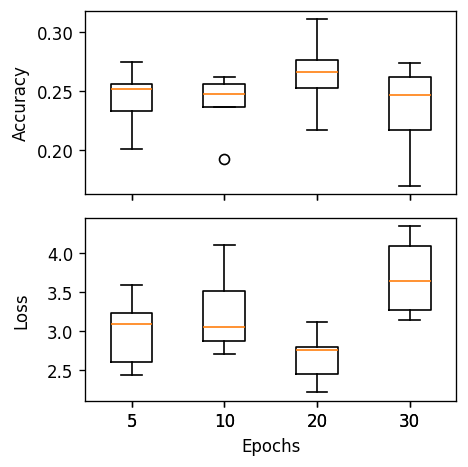

In [16]:
losses = np.zeros((n_repetitions, 4))
accurs = np.zeros((n_repetitions, 4))

for i, epochs in enumerate([5,10,20,30]):
    sample = df[(df['n_neurons'] == 1024) & (df['n_layers'] == 1)& (df['dropout'] == 0.25) & (df['optimizer'] == 'adam') & (df['epochs'] == epochs)]
    loss   = sample[[f'loss {i}' for i in  range(1, n_repetitions+1)]].to_numpy()
    accy   = sample[[f'accuracy {i}' for i in  range(1, n_repetitions+1)]].to_numpy()

    losses[:, i] = loss
    accurs[:, i] = accy

fig,ax=plt.subplots(2,1,figsize=(4,4),dpi=120,sharex=True)

ax[0].boxplot(accurs, tick_labels=[5,10,20,30])
ax[1].boxplot(losses, tick_labels=[5,10,20,30])

ax[0].set_ylabel('Accuracy')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epochs')
fig.align_ylabels()
plt.tight_layout()

In [17]:
# Please, replace the values obtained by the simplified grid search here and execute the code
d = model_and_evaluate(n_neurons=2048,
                       n_layers=1,
                       dropout=0.0,
                       optimizer='SGD',
                       epochs=30)

Epoch 1/30
1563/1563 [==============================] - 13s 8ms/step - loss: 1.9611 - accuracy: 0.3041
Epoch 2/30
1563/1563 [==============================] - 12s 8ms/step - loss: 1.8491 - accuracy: 0.3489
Epoch 3/30
1563/1563 [==============================] - 12s 8ms/step - loss: 1.8204 - accuracy: 0.3612
Epoch 4/30
1563/1563 [==============================] - 12s 8ms/step - loss: 1.8147 - accuracy: 0.3665
Epoch 5/30
1563/1563 [==============================] - 13s 8ms/step - loss: 1.8144 - accuracy: 0.3667
Epoch 6/30
1563/1563 [==============================] - 12s 8ms/step - loss: 1.8188 - accuracy: 0.3668
Epoch 7/30
1563/1563 [==============================] - 12s 8ms/step - loss: 1.8373 - accuracy: 0.3644
Epoch 8/30
1563/1563 [==============================] - 12s 8ms/step - loss: 1.8621 - accuracy: 0.3582
Epoch 9/30
1563/1563 [==============================] - 14s 9ms/step - loss: 1.8877 - accuracy: 0.3536
Epoch 10/30
1563/1563 [==============================] - 13s 9ms/step - l